In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.thesis_plots import *
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [13]:
pickles = [
    '../NR37/multiblock/Output/NASAR37.pik',
    '../HECC/multiblock/Output/NASA_HECC.pik',
]

data = []
for pik in pickles:
    with open(pik, 'rb') as f:
        data.append(pickle.load(f))

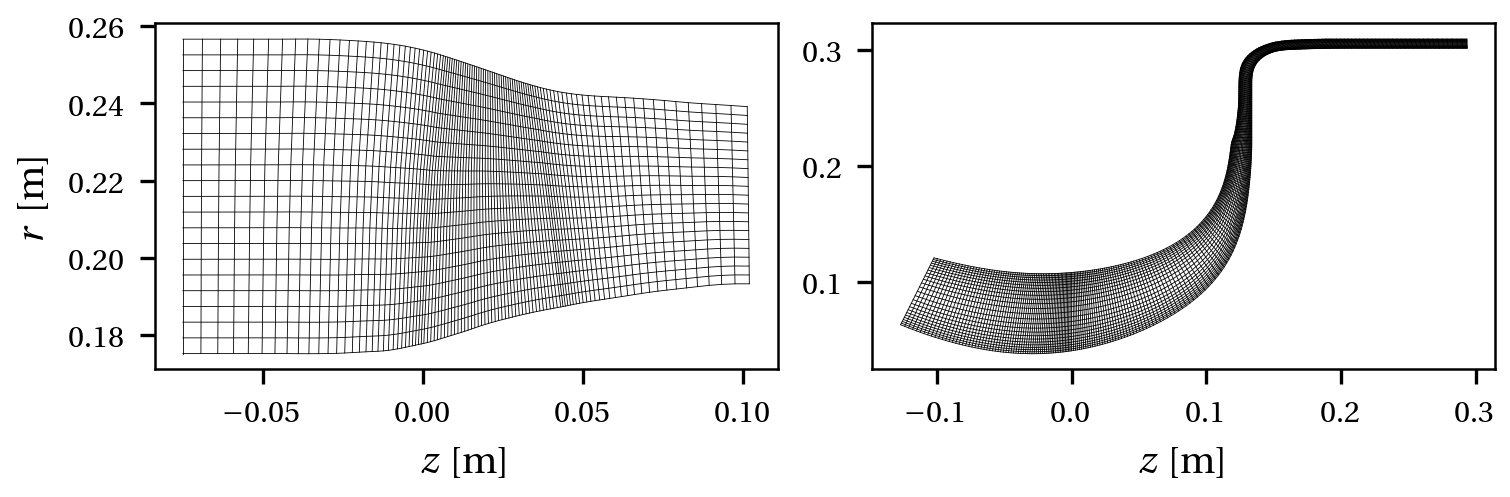

In [27]:
set_thesis_style()
fig, ax = create_figure(fraction=1.0, aspect_ratio=1.53, subplots=(1,2))

for imachine, machine in enumerate(data):
    rgrid = machine.multiBlockGrid.r_grid
    zgrid = machine.multiBlockGrid.z_grid
    ni, nj = rgrid.shape
    
    skip_ni = 1
    skip_nj = 2
    for ii in range(0, ni, skip_ni):
        ax[imachine].plot(zgrid[ii, :], rgrid[ii, :], '-k', linewidth=0.2)
    for jj in range(0, nj, skip_nj):
        ax[imachine].plot(zgrid[:, jj], rgrid[:, jj], '-k', linewidth=0.2)

for axx in ax:
    axx.set_xlabel(r'$z$ [m]')
ax[0].set_ylabel(r'$r$ [m]')
fig.savefig('sketch_nr37_nhecc.pdf')